# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [6]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [7]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [8]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [9]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [10]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [14]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [15]:
# Tabla OneHotEncoder
onehot_encoder.head()



,embarked_C,embarked_Q,embarked_S
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True


In [17]:
from sklearn.preprocessing import OrdinalEncoder

# 1. Definir el orden lógico (de menor a mayor importancia o viceversa)
# Es vital pasarlo como una lista de listas
orden_clases = [['Third', 'Second', 'First']]

# 2. Instanciar el codificador con el orden definido
ordinal_encoder = OrdinalEncoder(categories=orden_clases)

# 3. Aplicar la transformación
# Usamos double corchete [[ ]] porque OrdinalEncoder espera una matriz 2D
data['class_encoded'] = ordinal_encoder.fit_transform(data[['class']])

# Visualizar el resultado
print("Mapeo Ordinal (0: Third, 1: Second, 2: First):")
data[['class', 'class_encoded']].head(10)

Mapeo Ordinal (0: Third, 1: Second, 2: First):


,class,class_encoded
0,Third,0.0
1,First,2.0
2,Third,0.0
3,First,2.0
4,Third,0.0
5,Third,0.0
6,First,2.0
7,Third,0.0
8,Third,0.0
9,Second,1.0


In [18]:
# 1. Combinar (lo que ya tienes)
data = pd.concat([data, onehot_encoder], axis=1)

# 2. Eliminar la columna original 'embarked' (ya no la necesitamos)
# También eliminamos 'embark_town' si existe, para evitar redundancia
columns_to_drop = ['embarked', 'embark_town']
data.drop(columns=[c for c in columns_to_drop if c in data.columns], inplace=True)

# 3. Ver el resultado final de la transformación
print("Dataset transformado y limpio:")
data.head()

Dataset transformado y limpio:


,survived,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,deck,alive,alone,sex_label,class_encoded,embarked_C,embarked_Q,embarked_S
0,0,3,male,22.0,1,0,7.2500,Third,man,True,NaN,no,False,1,0.0,False,False,True
1,1,1,female,38.0,1,0,71.2833,First,woman,False,C,yes,False,0,2.0,True,False,False
2,1,3,female,26.0,0,0,7.9250,Third,woman,False,NaN,yes,True,0,0.0,False,False,True
3,1,1,female,35.0,1,0,53.1000,First,woman,False,C,yes,False,0,2.0,False,False,True
4,0,3,male,35.0,0,0,8.0500,Third,man,True,NaN,no,True,1,0.0,False,False,True


# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [19]:
# --- DEMOSTRACIÓN DE DIFERENCIAS ---

# 1. LabelEncoder en 'sex': Perfecto para binarios
# El modelo entiende: 0 es diferente de 1. No hay riesgo de jerarquía compleja.
print(f"Mapeo LabelEncoder (sex): {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

# 2. OneHotEncoder en 'embarked': Vital para evitar jerarquías falsas
# Si hubiéramos usado LabelEncoder, 'S' (2) sería "más grande" que 'C' (0).
# Con One-Hot, cada puerto es su propia dimensión independiente.
print("\nColumnas generadas por One-Hot (embarked):")
print(onehot_encoder.columns.tolist())

# 3. Verificación de tipos (Lo que discutimos de True/False)
print("\nTipos de datos finales en las columnas de embarked:")
print(data[onehot_encoder.columns].dtypes)

Mapeo LabelEncoder (sex): {'female': np.int64(0), 'male': np.int64(1)}

Columnas generadas por One-Hot (embarked):
['embarked_C', 'embarked_Q', 'embarked_S']

Tipos de datos finales en las columnas de embarked:
embarked_C    bool
embarked_Q    bool
embarked_S    bool
dtype: object


### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

C:\Users\jleyv\AppData\Local\Temp\ipykernel_3128\243002337.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='sex', ax=axes[0], palette='viridis')
C:\Users\jleyv\AppData\Local\Temp\ipykernel_3128\243002337.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='sex_label', ax=axes[1], palette='viridis')


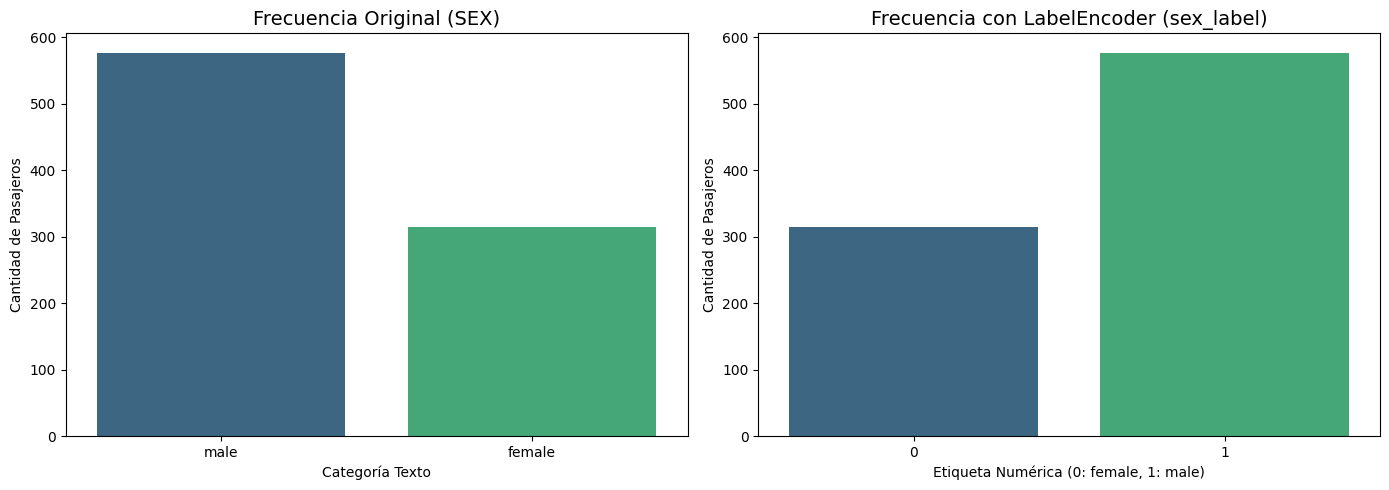

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del lienzo para dos gráficas en paralelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gráfica Antes (Original - Categórica)
sns.countplot(data=data, x='sex', ax=axes[0], palette='viridis')
axes[0].set_title('Frecuencia Original (SEX)', fontsize=14)
axes[0].set_xlabel('Categoría Texto')
axes[0].set_ylabel('Cantidad de Pasajeros')

# 2. Gráfica Después (Codificada - Numérica)
sns.countplot(data=data, x='sex_label', ax=axes[1], palette='viridis')
axes[1].set_title('Frecuencia con LabelEncoder (sex_label)', fontsize=14)
axes[1].set_xlabel('Etiqueta Numérica (0: female, 1: male)')
axes[1].set_ylabel('Cantidad de Pasajeros')

# Ajustar diseño para evitar traslapes
plt.tight_layout()
plt.show()

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [21]:
# Aplicar One-Hot Encoding a la columna 'class'
onehot_class = pd.get_dummies(data['class'], prefix='class')

# Unir al DataFrame original y eliminar la columna de texto
data = pd.concat([data, onehot_class], axis=1)
data.drop('class', axis=1, inplace=True)

# Visualizar el cambio
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,deck,alive,alone,sex_label,class_encoded,embarked_C,embarked_Q,embarked_S,class_First,class_Second,class_Third
0,0,3,male,22.0,1,0,7.2500,man,True,NaN,no,False,1,0.0,False,False,True,False,False,True
1,1,1,female,38.0,1,0,71.2833,woman,False,C,yes,False,0,2.0,True,False,False,True,False,False
2,1,3,female,26.0,0,0,7.9250,woman,False,NaN,yes,True,0,0.0,False,False,True,False,False,True
3,1,1,female,35.0,1,0,53.1000,woman,False,C,yes,False,0,2.0,False,False,True,True,False,False
4,0,3,male,35.0,0,0,8.0500,man,True,NaN,no,True,1,0.0,False,False,True,False,False,True


Si no se elimina la jerarquia que hace Labelencoder u OrdinalEncoder un algoritmo de regresion lineal podria asignar erroneamente mas pero a una variable que a otra causando un error, entonces OnHotencoder podria ser la solucion si el peso del dato no es relevante, pero como en este caso si es de peso por que es la "class", y est oafecta el proceso de probabilidad de supervivencia del ejercicio, me quedo con OrdinalEncoder.

### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

Para las variables categóricas: 'sex' , 'class' y 'embarked'
'sex': LabelEncoding, es sencillo por que solamente tengo 2 variables, male/female puedo usar 0/1
'class': OrdinalEncoding, por que las clases tiene peso y ese peso debe reflejarse en el resultado    del modelo de aprendizaje para sumar a la probabilidad.
'embarked': OnHotEncoder, porque aquí hay 3 variables y los datos no reflejan ningún peso diferenciador para el análisis del dataset, es decir que donde hayan embarcado no es tan importante y no impacta el saber si sobrevivió o no.